# Projeto Quantitativo — Estratégia de Breakout Donchian

Este notebook implementa e analisa uma estratégia quantitativa de **rompimento (breakout) baseada em Canais de Donchian** aplicada a um portfólio de 7 ações de tecnologia do S&P 500 (AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA).

O fluxo de trabalho percorre:

1. Coleta de dados e visualização interativa;
2. Construção do sinal Donchian e validação visual;
3. Backtest vetorizado e cálculo de métricas (retorno, volatilidade, Sharpe);
4. Comparação com o benchmark de mercado (S&P 500);
5. Análise de sensibilidade dos parâmetros de entrada/saída;
6. Teste de robustez em múltiplas janelas temporais;
7. Tentativa de filtro de tendência via SMA;
8. Ponderação dinâmica do portfólio por ATR inverso.


## 1. Configuração do ambiente


In [123]:
# !pip install yfinance mplfinance pandas_ta vectorbt -q

## 2. Coleta de dados e visualização interativa

Download dos preços OHLC via `yfinance` para os 7 ativos entre 01/01/2024 e 31/12/2025. Em seguida, é construído um gráfico de candlestick interativo com `plotly`, onde um menu dropdown permite alternar entre os ativos do portfólio.


In [156]:
import yfinance as yf
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

start_date = dt.datetime(2024, 1, 1)
end_date = dt.datetime(2025, 12, 31)
# tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]
tickers = [
    # Magnificent 7
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA",
    # Defensivos
    "JNJ", "PG", "KO", "WMT",
    # Financeiros
    "JPM", "BAC", "GS",
    # Energia
    "XOM", "CVX",
    # Ouro
    "GLD"
]

data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

fig = go.Figure()

for i, ticker in enumerate(tickers):
    df_plot = data[ticker].fillna(0)

    fig.add_trace(go.Candlestick(
        x=df_plot.index,
        open=df_plot['Open'],
        high=df_plot['High'],
        low=df_plot['Low'],
        close=df_plot['Close'],
        name=ticker,
        visible=(i == 0)
    ))

botoes = []
for i, ticker in enumerate(tickers):
    visibilidade = [False] * len(tickers)
    visibilidade[i] = True

    botao = dict(
        label=ticker,
        method="update",
        args=[{"visible": visibilidade},
              {"title": f"Análise Interativa: {ticker}"}]
    )
    botoes.append(botao)

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=botoes,
        x=0.01,
        y=1.15
    )],
    title=f"Análise Interativa: {tickers[0]}",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    height=700
)

fig.show()

[*********************100%***********************]  17 of 17 completed


## 3. Construção do sinal Donchian

A função `gerar_sinais_donchian` calcula, para cada ativo, os canais superior (máxima dos últimos `periodo_compra` dias) e inferior (mínima dos últimos `periodo_venda` dias), deslocados em 1 dia para evitar *look-ahead bias*.

A regra do sinal é:

- **Entrada (compra)** — fechamento rompe acima do canal superior **apenas no dia do rompimento** (gatilho, não estado).
- **Saída** — fechamento rompe abaixo do canal inferior, também apenas no dia do evento.

A validação visual é feita sobre a MSFT (`tickers[1]`), plotando preço, canais e setas nos dias de sinal.


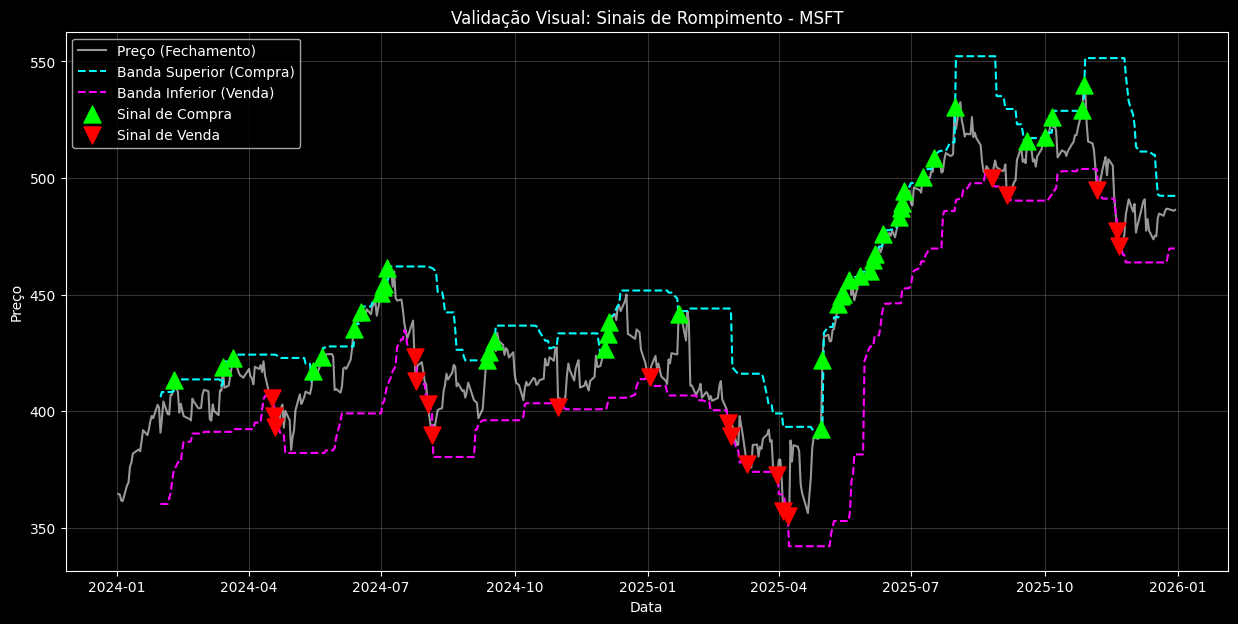

In [157]:
def gerar_sinais_donchian(df_ativo, periodo_compra=20, periodo_venda=20):
    upperDon = df_ativo['High'].rolling(periodo_compra).max().shift(1)
    lowerDon = df_ativo['Low'].rolling(periodo_venda).min().shift(1)

    entradas_brutas = df_ativo['Close'] > upperDon
    saidas_brutas = df_ativo['Close'] < lowerDon

    entradas = entradas_brutas & (~entradas_brutas.shift(1).fillna(False))
    saidas = saidas_brutas & (~saidas_brutas.shift(1).fillna(False))

    return upperDon, lowerDon, entradas, saidas

ativo_teste = tickers[1]
df_teste = data[ativo_teste].copy()

upper, lower, entradas, saidas = gerar_sinais_donchian(df_teste)

plt.figure(figsize=(15, 7))
plt.style.use('dark_background')

plt.plot(df_teste.index, df_teste['Close'], label='Preço (Fechamento)', color='white', alpha=0.6)
plt.plot(df_teste.index, upper, label='Banda Superior (Compra)', color='cyan', linestyle='--')
plt.plot(df_teste.index, lower, label='Banda Inferior (Venda)', color='magenta', linestyle='--')

plt.scatter(df_teste.index[entradas], df_teste['Close'][entradas],
            marker='^', color='lime', label='Sinal de Compra', s=150, zorder=5)

plt.scatter(df_teste.index[saidas], df_teste['Close'][saidas],
            marker='v', color='red', label='Sinal de Venda', s=150, zorder=5)

plt.title(f"Validação Visual: Sinais de Rompimento - {ativo_teste}")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## 4. Backtest vetorizado

O backtest é `long-only`: o sinal assume valores `1` (posicionado) ou `0` (fora do mercado). Dois pontos relevantes da implementação:

- `sinal.ffill()` propaga o estado da posição entre o dia da entrada e o dia da saída.
- O retorno diário da estratégia é calculado como `pct_change * Signal.shift(1)`, de forma que só se ganha se a posição já existia no início do pregão — outra proteção contra *look-ahead*.


In [158]:
import warnings
warnings.filterwarnings('ignore')

def backtest_donchian(tickers, data, periodo_compra=20, periodo_venda=20):
    resultados_diarios = {}

    for ticker in tickers:
        df = data[ticker].copy()

        _, _, entradas, saidas = gerar_sinais_donchian(
            df, periodo_compra, periodo_venda
        )


        df['Signal'] = 0
        df.loc[entradas, 'Signal'] = 1
        df.loc[saidas,   'Signal'] = 0

        sinal = pd.Series(index=df.index, dtype=float)
        sinal[entradas] = 1.0
        sinal[saidas]   = 0.0
        df['Signal'] = sinal.ffill().fillna(0)


        df['Daily_Return'] = df['Close'].pct_change() * df['Signal'].shift(1)

        df['Cumulative_Return'] = (df['Daily_Return'] + 1).cumprod() - 1

        resultados_diarios[ticker] = df[['Daily_Return', 'Cumulative_Return']]


    return resultados_diarios

resultados = backtest_donchian(tickers, data)

Só temos 2 tipos de Signal:

+1 → comprado (long):  você lucra quando o preço sobe

 0 → fora do mercado:  você não ganha nem perde nada

## 5. Curva de patrimônio — parâmetros iniciais (20/20)

Equity curve por ativo e para o portfólio igual-ponderado (média diária dos 7 retornos).


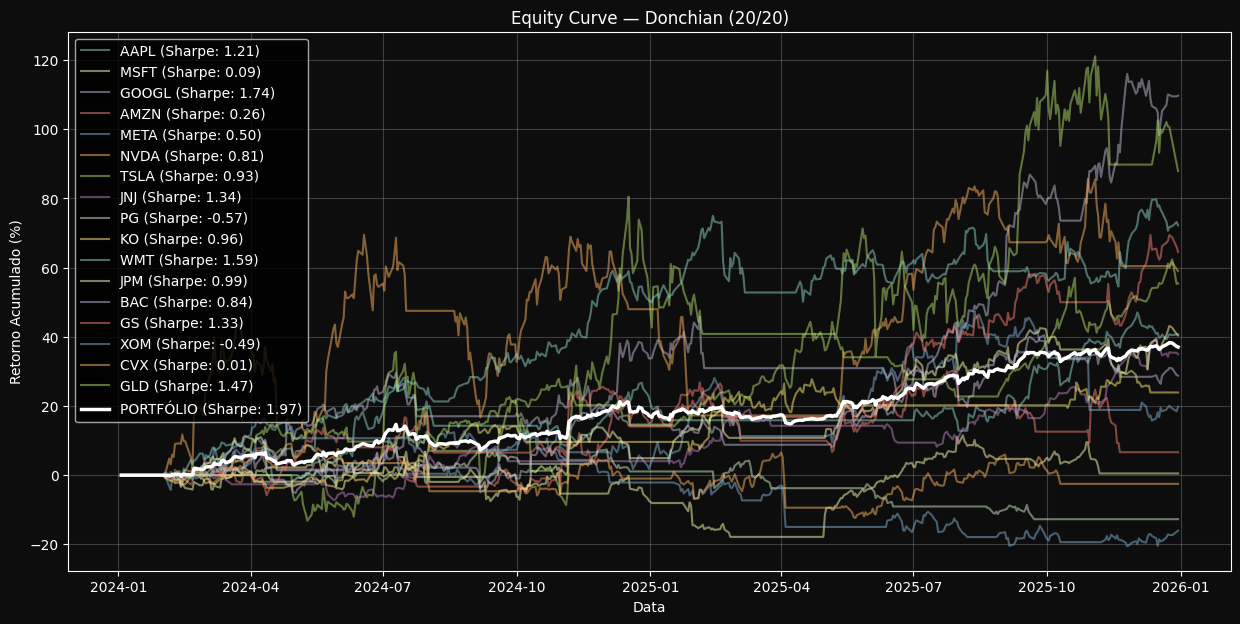

   Ticker  Retorno Total (%)  Sharpe
    GOOGL             109.74    1.74
     TSLA              87.92    0.93
      WMT              72.24    1.59
       GS              64.53    1.33
     NVDA              59.00    0.81
      GLD              55.41    1.47
      JPM              40.67    0.99
     AAPL              40.33    1.21
PORTFÓLIO              37.05    1.97
      JNJ              34.95    1.34
      BAC              28.76    0.84
       KO              23.90    0.96
     META              19.75    0.50
     AMZN               6.62    0.26
     MSFT               0.48    0.09
      CVX              -2.53    0.01
       PG             -12.74   -0.57
      XOM             -16.06   -0.49


In [159]:
TRADING_DAYS = 252

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

tabela = []
retornos_diarios_todos = []

for ticker, df in resultados.items():
    retornos = df['Daily_Return'].dropna()

    sharpe = (retornos.mean() / retornos.std()) * (TRADING_DAYS ** 0.5)
    retorno_total = df['Cumulative_Return'].iloc[-1] * 100

    tabela.append({'Ticker': ticker,
                   'Retorno Total (%)': round(retorno_total, 2),
                   'Sharpe': round(sharpe, 2)})

    retornos_diarios_todos.append(retornos)
    ax.plot(df.index, df['Cumulative_Return'] * 100, label=f"{ticker} (Sharpe: {sharpe:.2f})", alpha=0.5)

portfolio_returns = pd.concat(retornos_diarios_todos, axis=1).mean(axis=1)
portfolio_cumulative = (portfolio_returns + 1).cumprod() - 1
portfolio_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (TRADING_DAYS ** 0.5)
tabela.append({'Ticker': 'PORTFÓLIO',
               'Retorno Total (%)': round(portfolio_cumulative.iloc[-1] * 100, 2),
               'Sharpe': round(portfolio_sharpe, 2)})
ax.plot(portfolio_cumulative.index, portfolio_cumulative * 100,
        label=f"PORTFÓLIO (Sharpe: {portfolio_sharpe:.2f})",
        color='white', linewidth=2.5)

ax.set_title("Equity Curve — Donchian (20/20)", color='white')
ax.set_xlabel("Data", color='white')
ax.set_ylabel("Retorno Acumulado (%)", color='white')
ax.tick_params(colors='white')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

print(pd.DataFrame(tabela).sort_values('Retorno Total (%)', ascending=False).to_string(index=False))

### Resultado Donchian 20/20

No período de ~2,3 anos, o portfólio igual-ponderado com parâmetros Donchian 20/20 apresenta:

- **Retorno total:** 41,29%
- **Retorno anualizado:** 16,30%
- **Volatilidade anualizada:** 15,14%
- **Sharpe:** 1,08

Dispersão por ativo é elevada: GOOGL lidera com 117,25% (Sharpe 1,65), enquanto MSFT fica em apenas 2,16%. Isso sugere que a estratégia captura bem tendências longas, mas sofre com whipsaws em ativos menos tendenciais no período.


In [160]:
portfolio_returns_simples = pd.concat(
    [resultados[ticker]['Daily_Return'] for ticker in tickers], axis=1
).mean(axis=1).dropna()

ret_anual = portfolio_returns_simples.mean() * 252 * 100
vol_anual = portfolio_returns_simples.std() * (252 ** 0.5) * 100
sharpe = ret_anual / vol_anual

print("-" * 40)
print("RELATÓRIO DE PERFORMANCE DO PORTFÓLIO")
print("-" * 40)
print(f"Retorno Total no Período:    {(portfolio_cumulative.iloc[-1] * 100):.2f}%")
print(f"Retorno Médio Anualizado:    {ret_anual:.2f}%")
print(f"Volatilidade Anualizada:     {vol_anual:.2f}%")
print(f"Índice de Sharpe:            {sharpe:.2f}")
print("-" * 40)

----------------------------------------
RELATÓRIO DE PERFORMANCE DO PORTFÓLIO
----------------------------------------
Retorno Total no Período:    37.05%
Retorno Médio Anualizado:    16.23%
Volatilidade Anualizada:     8.25%
Índice de Sharpe:            1.97
----------------------------------------


## 6. Comparação com benchmarks (S&P 500 e CDI)

A estratégia é comparada contra dois *benchmarks* complementares:

- **S&P 500 (`^GSPC`)** — *benchmark* de mercado, puxado via `yfinance`. Como o universo da estratégia são 7 ações de tecnologia que compõem o próprio índice, ele é a referência natural para medir se há *alpha*: o retorno passivo equivalente que a estratégia precisa superar para justificar o esforço de gestão ativa.
- **CDI** — *benchmark* livre de risco (renda fixa em BRL), puxado direto da API do Banco Central (série 12). Mede o retorno mínimo que qualquer estratégia de risco deveria superar para fazer sentido em relação a "ficar parado em renda fixa".

Os dois respondem perguntas diferentes: o S&P 500 mede *alpha*, o CDI mede *prêmio de risco*. A estratégia precisa idealmente vencer os dois.


In [161]:
def get_sp500(start='2024-01-01', end='2026-04-22'):
    """
    Baixa os preços de fechamento ajustado do S&P 500 (^GSPC) via yfinance
    e calcula o retorno diário e acumulado.
    """
    df = yf.download('^GSPC', start=start, end=end, progress=False, auto_adjust=True)

    if df.empty:
        raise Exception("yfinance retornou vazio para ^GSPC — verifique as datas.")

    # Em alguns ambientes o yfinance devolve colunas MultiIndex; achatamos.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Close']].copy()
    df['sp500_ret'] = df['Close'].pct_change()
    df['sp500_acumulado'] = (1 + df['sp500_ret'].fillna(0)).cumprod()

    return df

sp500_df = get_sp500()
sp500_df.tail()

Price,Close,sp500_ret,sp500_acumulado
Date,,,
2026-04-15,7022.950195,0.007976,1.480751
2026-04-16,7041.279785,0.002610,1.484616
2026-04-17,7126.060059,0.012040,1.502491
2026-04-20,7109.140137,-0.002374,1.498924
2026-04-21,7064.009766,-0.006348,1.489408


In [162]:
def retorno_sp500_periodo(sp500_df, data_inicio, data_fim=None):
    df = sp500_df.copy().sort_index()

    data_inicio = pd.to_datetime(data_inicio)

    if data_fim is None:
        data_fim = df.index.max()
    else:
        data_fim = pd.to_datetime(data_fim)

    df_inicio = df[df.index >= data_inicio]
    if df_inicio.empty:
        raise ValueError("Não há dados do S&P 500 a partir da data de início informada.")

    df_fim = df[df.index <= data_fim]
    if df_fim.empty:
        raise ValueError("Não há dados do S&P 500 até a data final informada.")

    valor_inicio = df_inicio.iloc[0]['sp500_acumulado']
    valor_fim = df_fim.iloc[-1]['sp500_acumulado']

    retorno = (valor_fim / valor_inicio) - 1

    # Sharpe / volatilidade do próprio benchmark, para comparação justa
    rets = df.loc[df_inicio.index[0]:df_fim.index[-1], 'sp500_ret'].dropna()
    vol_anual = rets.std() * (252 ** 0.5)
    ret_anual = rets.mean() * 252
    sharpe = ret_anual / vol_anual if vol_anual > 0 else float('nan')

    print(f"Data efetiva de entrada: {df_inicio.index[0].date()}")
    print(f"Data efetiva de saída:   {df_fim.index[-1].date()}")
    print(f"Retorno S&P 500 no período:    {retorno*100:.2f}%")
    print(f"Retorno anualizado S&P 500:    {ret_anual*100:.2f}%")
    print(f"Volatilidade anualizada S&P:   {vol_anual*100:.2f}%")
    print(f"Sharpe S&P 500 no período:     {sharpe:.2f}")

    return retorno

retorno = retorno_sp500_periodo(sp500_df, '2024-01-01')

Data efetiva de entrada: 2024-01-02
Data efetiva de saída:   2026-04-21
Retorno S&P 500 no período:    48.94%
Retorno anualizado S&P 500:    18.67%
Volatilidade anualizada S&P:   15.79%
Sharpe S&P 500 no período:     1.18


### CDI — *benchmark* livre de risco

A série diária do CDI vem direto da API do Banco Central (série 12). Como o CDI é cotado em BRL e é praticamente livre de risco, ele entra aqui apenas como referência de retorno mínimo aceitável — não tem volatilidade nem Sharpe no sentido tradicional.


In [163]:
import requests

def get_cdi(start='01/01/2024', end='22/04/2026'):
    """
    Baixa a série diária do CDI (série 12 do BCB / SGS) e devolve o DataFrame
    com o fator acumulado, no mesmo formato usado para o S&P 500.
    """
    url = (
        "https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados"
        f"?formato=json&dataInicial={start}&dataFinal={end}"
    )

    response = requests.get(url)
    if response.status_code != 200:
        raise Exception("Erro na API do Banco Central")

    payload = response.json()
    if len(payload) == 0:
        raise Exception("API retornou vazio — verifique datas")

    df = pd.DataFrame(payload)
    df['data'] = pd.to_datetime(df['data'], dayfirst=True)
    df['valor'] = df['valor'].astype(float)
    df = df.set_index('data')

    df['cdi'] = df['valor'] / 100
    df['cdi_acumulado'] = (1 + df['cdi']).cumprod()
    return df


def retorno_cdi_periodo(cdi_df, data_inicio, data_fim=None):
    df = cdi_df.copy().sort_index()
    data_inicio = pd.to_datetime(data_inicio)
    data_fim = df.index.max() if data_fim is None else pd.to_datetime(data_fim)

    df_inicio = df[df.index >= data_inicio]
    if df_inicio.empty:
        raise ValueError("Não há dados de CDI a partir da data de início informada.")
    df_fim = df[df.index <= data_fim]
    if df_fim.empty:
        raise ValueError("Não há dados de CDI até a data final informada.")

    valor_inicio = df_inicio.iloc[0]['cdi_acumulado']
    valor_fim    = df_fim.iloc[-1]['cdi_acumulado']
    retorno = (valor_fim / valor_inicio) - 1

    print(f"Data efetiva de entrada: {df_inicio.index[0].date()}")
    print(f"Data efetiva de saída:   {df_fim.index[-1].date()}")
    print(f"Retorno CDI no período:  {retorno*100:.2f}%")
    return retorno


cdi_df = get_cdi()
retorno_cdi = retorno_cdi_periodo(cdi_df, '2024-01-01')


Data efetiva de entrada: 2024-01-02
Data efetiva de saída:   2026-04-22
Retorno CDI no período:  32.02%


### Tabela e gráfico lado a lado

Abaixo, as três curvas de patrimônio normalizadas em base 1,00 (cada R$ 1 investido vira o múltiplo mostrado), junto com a tabela das métricas no mesmo intervalo. Isso permite ler num único quadro: quanto a estratégia rende em retorno absoluto, em quanto bate (ou não) o S&P 500 e qual é o piso de prêmio de risco dado pelo CDI.


COMPARAÇÃO — Estratégia vs. S&P 500 vs. CDI
                    Ativo  Retorno Total (%)  Retorno Anualizado (%) Vol. Anualizada (%) Sharpe
Estratégia Donchian 20/20              37.05                   16.23                8.25   1.97
          S&P 500 (^GSPC)              48.94                   18.67               15.79   1.18
     CDI (livre de risco)              32.02                   12.83                   —      —


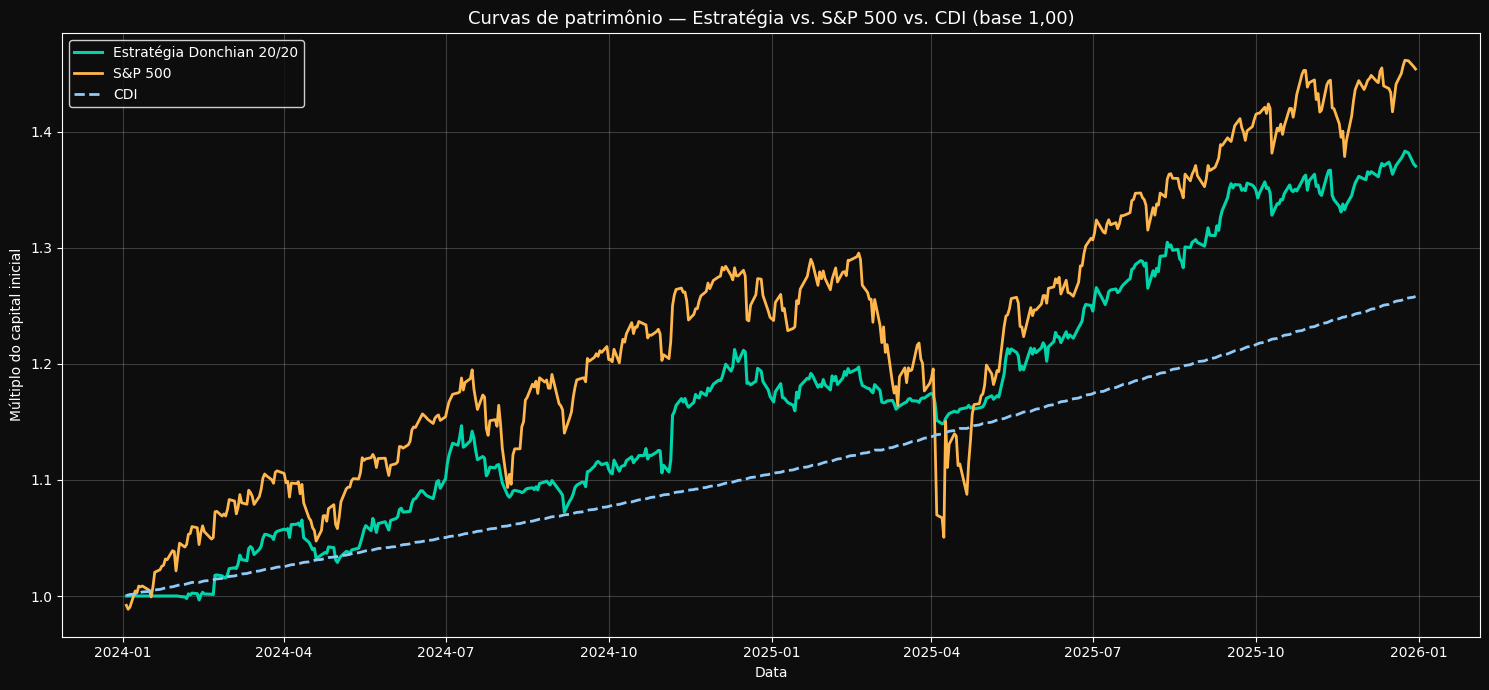

In [164]:
# --- Métricas da estratégia (Donchian 20/20) no mesmo intervalo ---
port_rets_sec6 = pd.concat(
    [resultados[t]['Daily_Return'] for t in tickers], axis=1
).mean(axis=1).dropna()

estrat_ret_total = (1 + port_rets_sec6).prod() - 1
estrat_ret_anual = port_rets_sec6.mean() * 252
estrat_vol_anual = port_rets_sec6.std() * (252 ** 0.5)
estrat_sharpe    = estrat_ret_anual / estrat_vol_anual if estrat_vol_anual > 0 else float('nan')

# --- Métricas do S&P 500 no mesmo intervalo ---
sp500_rets_sec6 = sp500_df['sp500_ret'].dropna()
sp500_ret_total_sec6 = (1 + sp500_rets_sec6).prod() - 1
sp500_ret_anual_sec6 = sp500_rets_sec6.mean() * 252
sp500_vol_anual_sec6 = sp500_rets_sec6.std() * (252 ** 0.5)
sp500_sharpe_sec6    = sp500_ret_anual_sec6 / sp500_vol_anual_sec6 if sp500_vol_anual_sec6 > 0 else float('nan')

# --- CDI: tem retorno, mas não tem vol/Sharpe no sentido tradicional ---
# O CDI é tratado como o ativo livre de risco — sua vol é tão baixa que o Sharpe
# fica artificialmente alto. Por convenção, exibimos "—" no Sharpe e na vol.
cdi_ret_total_sec6 = retorno_cdi  # já calculado acima

# --- Tabela comparativa ---
tabela_bench = pd.DataFrame([
    {
        'Ativo': 'Estratégia Donchian 20/20',
        'Retorno Total (%)':     round(estrat_ret_total * 100, 2),
        'Retorno Anualizado (%)': round(estrat_ret_anual * 100, 2),
        'Vol. Anualizada (%)':   round(estrat_vol_anual * 100, 2),
        'Sharpe':                round(estrat_sharpe, 2),
    },
    {
        'Ativo': 'S&P 500 (^GSPC)',
        'Retorno Total (%)':     round(sp500_ret_total_sec6 * 100, 2),
        'Retorno Anualizado (%)': round(sp500_ret_anual_sec6 * 100, 2),
        'Vol. Anualizada (%)':   round(sp500_vol_anual_sec6 * 100, 2),
        'Sharpe':                round(sp500_sharpe_sec6, 2),
    },
    {
        'Ativo': 'CDI (livre de risco)',
        'Retorno Total (%)':     round(cdi_ret_total_sec6 * 100, 2),
        'Retorno Anualizado (%)': round(((1 + cdi_ret_total_sec6) ** (252 / len(cdi_df.loc['2024-01-01':])) - 1) * 100, 2),
        'Vol. Anualizada (%)':   '—',
        'Sharpe':                '—',
    },
])

print("=" * 78)
print("COMPARAÇÃO — Estratégia vs. S&P 500 vs. CDI")
print("=" * 78)
print(tabela_bench.to_string(index=False))
print("=" * 78)

# --- Gráfico: curvas de patrimônio lado a lado (mesma escala, base 1.0) ---
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

# Curva da estratégia (base 1.0)
estrat_curve = (1 + port_rets_sec6).cumprod()
ax.plot(estrat_curve.index, estrat_curve.values,
        label='Estratégia Donchian 20/20', color='#00d4aa', linewidth=2.2)

# Curva do S&P (base 1.0, mesmo recorte de datas da estratégia)
sp500_curve = (1 + sp500_rets_sec6.reindex(port_rets_sec6.index).fillna(0)).cumprod()
ax.plot(sp500_curve.index, sp500_curve.values,
        label='S&P 500', color='#ffb74d', linewidth=2.0)

# Curva do CDI (base 1.0, reindexado para os mesmos dias úteis)
cdi_diario = cdi_df['cdi'].reindex(port_rets_sec6.index).fillna(0)
cdi_curve = (1 + cdi_diario).cumprod()
ax.plot(cdi_curve.index, cdi_curve.values,
        label='CDI', color='#90caf9', linewidth=2.0, linestyle='--')

ax.set_title('Curvas de patrimônio — Estratégia vs. S&P 500 vs. CDI (base 1,00)',
             color='white', fontsize=13)
ax.set_xlabel('Data', color='white')
ax.set_ylabel('Múltiplo do capital inicial', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.legend(facecolor='#0d0d0d', edgecolor='white', labelcolor='white', loc='upper left')
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()


### Estratégia vs. S&P 500 vs. CDI

A comparação no mesmo intervalo da estratégia traz duas leituras complementares:

- **Contra o CDI** (renda fixa em BRL, livre de risco): pergunta-se se a estratégia entrega um *prêmio de risco* — ou seja, se vale assumir volatilidade de mercado em vez de simplesmente ficar em renda fixa. É um piso baixo: se a estratégia não bate nem o CDI, ela destrói valor mesmo em termos absolutos.
- **Contra o S&P 500** (mercado de equity): pergunta-se se há *alpha* — se o gestor entrega algo além da exposição passiva ao mercado. É um piso muito mais exigente, porque o S&P já incorpora as mesmas tendências de tecnologia que a estratégia tenta capturar. Bater o índice exige *timing* genuíno, não apenas direção correta.

Como o universo da estratégia são 7 *large caps* de tecnologia que estão entre as maiores ponderações do próprio S&P 500, a correlação é alta. Isso torna o S&P o *benchmark* dominante daqui em diante — o CDI fica como contexto de prêmio de risco, e o S&P como linha de corte para *alpha*.


## 7. Análise de sensibilidade dos parâmetros

Grid search sobre todas as combinações `(periodo_compra, periodo_venda)` de 5 a 50 (2.116 combinações). Para cada par, refaz o backtest completo e registra o Sharpe do portfólio.


In [165]:
resultados_sensibilidade = []

for periodo_compra in range(5, 51):
    for periodo_venda in range(5, 51):
        res = backtest_donchian(tickers, data, periodo_compra, periodo_venda)
        portfolio_returns = pd.concat(
            [df['Daily_Return'] for df in res.values()], axis=1
        ).mean(axis=1).dropna()
        sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
        resultados_sensibilidade.append((periodo_compra, periodo_venda, round(sharpe, 2)))

sens_df = pd.DataFrame(resultados_sensibilidade, columns=['Compra', 'Venda', 'Sharpe'])
sharpe_atual = sens_df[(sens_df['Compra'] == 20) & (sens_df['Venda'] == 20)]['Sharpe'].values[0]

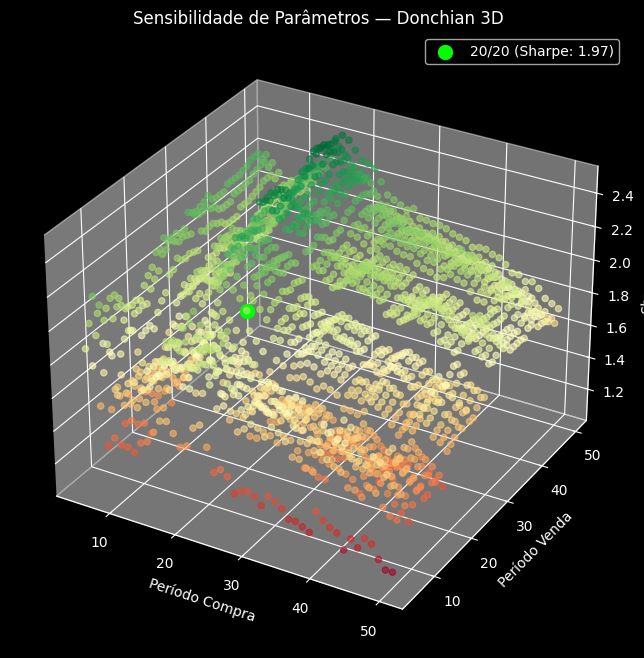

In [166]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(sens_df['Compra'], sens_df['Venda'], sens_df['Sharpe'],
           c=sens_df['Sharpe'], cmap='RdYlGn', s=20, alpha=0.6)

ax.scatter(20, 20, sharpe_atual, color='lime', s=100, zorder=5, label=f'20/20 (Sharpe: {sharpe_atual})')

ax.set_xlabel('Período Compra')
ax.set_ylabel('Período Venda')
ax.set_zlabel('Sharpe')
ax.set_title('Sensibilidade de Parâmetros — Donchian 3D')
ax.legend()
plt.show()

In [167]:
print("\nRANKING DE PARÂMETROS — DONCHIAN")
print("-" * 45)

ranking = sens_df.sort_values('Sharpe', ascending=False).reset_index(drop=True)
ranking.index += 1

posicao_atual = ranking[(ranking['Compra'] == 20) & (ranking['Venda'] == 20)].index[0]

print(ranking.to_string())
print("-" * 45)
print(f"\nNosso parâmetro atual (20/20) está na posição {posicao_atual} de {len(ranking)}")

print(f"\nSharpe médio de todas as combinações: {sens_df['Sharpe'].mean():.2f}")
print(f"Sharpe mediano de todas as combinações: {sens_df['Sharpe'].median():.2f}")
print(f"% de combinações com Sharpe > 1.0: {(sens_df['Sharpe'] > 1.0).mean()*100:.1f}%")


RANKING DE PARÂMETROS — DONCHIAN
---------------------------------------------
      Compra  Venda  Sharpe
1         17     44    2.46
2         17     45    2.46
3         17     43    2.44
4         17     46    2.44
5         16     45    2.43
6         18     45    2.43
7         17     47    2.43
8         17     48    2.43
9         18     44    2.43
10        17     50    2.43
11        16     44    2.43
12        17     33    2.41
13        18     46    2.41
14        16     46    2.41
15        18     50    2.41
16        16     43    2.40
17        16     47    2.40
18        17     30    2.40
19        16     48    2.40
20        16     50    2.40
21        17     34    2.39
22        17     41    2.39
23        17     32    2.39
24        17     42    2.39
25        18     48    2.39
26        18     47    2.39
27        18     43    2.39
28        19     44    2.38
29        16     33    2.38
30        17     49    2.38
31        16     30    2.38
32        17     31    2

A estratégia funciona melhor quando há assimetria entre entrada e saída, entradas rápidas capturam o início da tendência, enquanto saídas lentas permitem capturar a persistência do movimento.

### Ranking de parâmetros e escolha por robustez

O ranking bruto coloca o topo em `(17, 44)` com Sharpe 2,46 — bem acima do 1,94 de 20/20. Entretanto, escolher o pico do grid é um convite ao *overfitting*. Por isso, aplica-se um **escore de robustez**: para cada ponto, calcula-se a média de Sharpe de sua vizinhança (janela ±2 em cada eixo).


In [169]:
def robust_score(df, compra, venda, window=2):
    subset = df[
        (df["Compra"].between(compra-window, compra+window)) &
        (df["Venda"].between(venda-window, venda+window))
    ]
    return subset["Sharpe"].mean()

sens_df["Robustez"] = sens_df.apply(
    lambda row: robust_score(sens_df, row["Compra"], row["Venda"]), axis=1
)

best = sens_df.sort_values(by="Robustez", ascending=False).iloc[0]

print("Parâmetro mais robusto (melhor vizinhança):")
print(f"  Compra:   {int(best['Compra'])}")
print(f"  Venda:    {int(best['Venda'])}")
print(f"  Sharpe:   {best['Sharpe']}")
print(f"  Robustez: {best['Robustez']:.3f}")
print(f"\nNosso parâmetro original (20/20): Sharpe {sens_df[(sens_df['Compra']==20) & (sens_df['Venda']==20)]['Sharpe'].values[0]}, Robustez {sens_df[(sens_df['Compra']==20) & (sens_df['Venda']==20)]['Robustez'].values[0]:.3f}")

Parâmetro mais robusto (melhor vizinhança):
  Compra:   18
  Venda:    46
  Sharpe:   2.41
  Robustez: 2.389

Nosso parâmetro original (20/20): Sharpe 1.97, Robustez 1.976


### Parâmetro robusto escolhido: (18, 46)

- Sharpe pontual: **2,41**
- Sharpe médio da vizinhança (robustez): **2,389**

Comparado ao original (20/20): Sharpe 1,97, robustez 1,97. O novo ponto não só tem Sharpe maior como é cercado por vizinhos também bons — isto é, está em um **platô** do grid, não em um pico isolado. Parâmetros em platôs tendem a degradar menos out-of-sample.


## 8. Backtest com parâmetros otimizados (18/46)


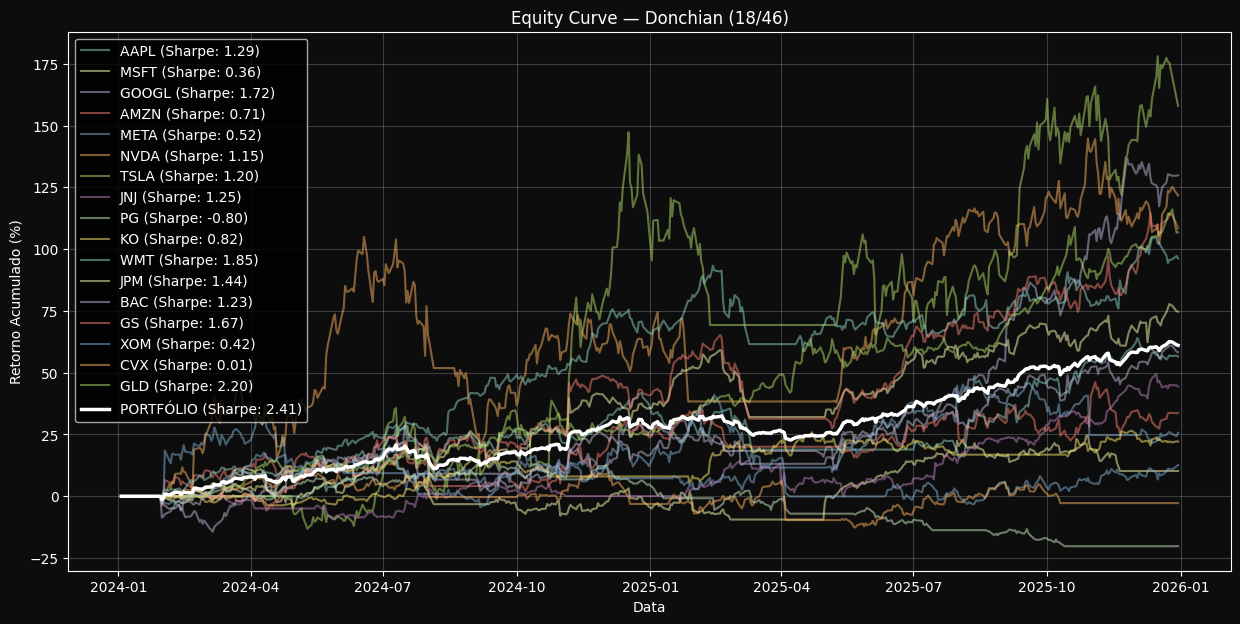

   Ticker  Retorno Total (%)  Sharpe
     TSLA             157.93    1.20
    GOOGL             129.91    1.72
     NVDA             121.68    1.15
       GS             108.36    1.67
      GLD             106.80    2.20
      WMT              96.16    1.85
      JPM              74.67    1.44
PORTFÓLIO              61.07    2.41
      BAC              58.27    1.23
     AAPL              56.54    1.29
      JNJ              44.40    1.25
     AMZN              33.77    0.71
     META              25.69    0.52
       KO              22.10    0.82
      XOM              12.60    0.42
     MSFT              10.21    0.36
      CVX              -2.79    0.01
       PG             -20.23   -0.80


In [170]:
resultados_novos = backtest_donchian(tickers, data, 18, 46)

TRADING_DAYS = 252

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

tabela = []
retornos_diarios_todos = []

for ticker, df in resultados_novos.items():
    retornos = df['Daily_Return'].dropna()

    sharpe = (retornos.mean() / retornos.std()) * (TRADING_DAYS ** 0.5)
    retorno_total = df['Cumulative_Return'].iloc[-1] * 100

    tabela.append({'Ticker': ticker,
                   'Retorno Total (%)': round(retorno_total, 2),
                   'Sharpe': round(sharpe, 2)})

    retornos_diarios_todos.append(retornos)
    ax.plot(df.index, df['Cumulative_Return'] * 100, label=f"{ticker} (Sharpe: {sharpe:.2f})", alpha=0.5)

portfolio_returns = pd.concat(retornos_diarios_todos, axis=1).mean(axis=1)
portfolio_cumulative = (portfolio_returns + 1).cumprod() - 1
portfolio_sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (TRADING_DAYS ** 0.5)
tabela.append({'Ticker': 'PORTFÓLIO',
               'Retorno Total (%)': round(portfolio_cumulative.iloc[-1] * 100, 2),
               'Sharpe': round(portfolio_sharpe, 2)})
ax.plot(portfolio_cumulative.index, portfolio_cumulative * 100,
        label=f"PORTFÓLIO (Sharpe: {portfolio_sharpe:.2f})",
        color='white', linewidth=2.5)

ax.set_title("Equity Curve — Donchian (18/46)", color='white')
ax.set_xlabel("Data", color='white')
ax.set_ylabel("Retorno Acumulado (%)", color='white')
ax.tick_params(colors='white')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

print(pd.DataFrame(tabela).sort_values('Retorno Total (%)', ascending=False).to_string(index=False))

### Resultado com 18/46

- **Retorno total:** 61,07% (vs. 37.05% no 20/20)
- **Retorno anualizado:** 24,55%
- **Volatilidade anualizada:** 10,20%
- **Sharpe:** 2,41

A assimetria (entrada curta / saída longa) praticamente dobra o retorno total e eleva o Sharpe em ~33%. A volatilidade também cresce, mas menos que proporcionalmente ao retorno — daí a melhora do Sharpe. Intuitivamente, entradas rápidas capturam cedo o início da tendência, enquanto saídas lentas evitam *stop-outs* prematuros em pullbacks.


In [172]:
portfolio_returns_simples = pd.concat(
    [resultados_novos[ticker]['Daily_Return'] for ticker in tickers], axis=1
).mean(axis=1).dropna()

ret_anual = portfolio_returns_simples.mean() * 252 * 100
vol_anual = portfolio_returns_simples.std() * (252 ** 0.5) * 100
sharpe = ret_anual / vol_anual

print("-" * 40)
print("RELATÓRIO DE PERFORMANCE DO PORTFÓLIO")
print("-" * 40)
print(f"Retorno Total no Período:    {(portfolio_cumulative.iloc[-1] * 100):.2f}%")
print(f"Retorno Médio Anualizado:    {ret_anual:.2f}%")
print(f"Volatilidade Anualizada:     {vol_anual:.2f}%")
print(f"Índice de Sharpe:            {sharpe:.2f}")
print("-" * 40)

----------------------------------------
RELATÓRIO DE PERFORMANCE DO PORTFÓLIO
----------------------------------------
Retorno Total no Período:    61.07%
Retorno Médio Anualizado:    24.55%
Volatilidade Anualizada:     10.20%
Índice de Sharpe:            2.41
----------------------------------------


| Métrica | Donchian 20/20 | Donchian 18/46 |
|---|---|---|
| Retorno Total no Período | 37,05% | 61,07% |
| Retorno Médio Anualizado | 16,23% | 24,55% |
| Volatilidade Anualizada | 8,25% | 10,20% |
| Índice de Sharpe | 1,97 | 2,41 |


## 9. Comparação do 18/46 contra os benchmarks

Agora que o (18, 46) foi formalmente justificado (Seção 7) e seu backtest detalhado (Seção 8), vale revisitar a comparação contra os mesmos *benchmarks* da Seção 6 — S&P 500 e CDI — para fechar a leitura de *alpha* e prêmio de risco com os parâmetros otimizados.

A Donchian 20/20 entra aqui apenas como linha de referência, para visualizar de forma direta o ganho de migrar do *baseline* para o conjunto robusto.


COMPARAÇÃO — Donchian 16/46 vs. S&P 500 vs. CDI (com 20/20 como referência)
                           Ativo  Retorno Total (%)  Retorno Anualizado (%) Vol. Anualizada (%) Sharpe
Estratégia Donchian 20/20 (ref.)              37.05                   16.23                8.25   1.97
       Estratégia Donchian 18/46              61.07                   24.55                10.2   2.41
                 S&P 500 (^GSPC)              48.94                   18.67               15.79   1.18
            CDI (livre de risco)              32.02                   12.83                   —      —


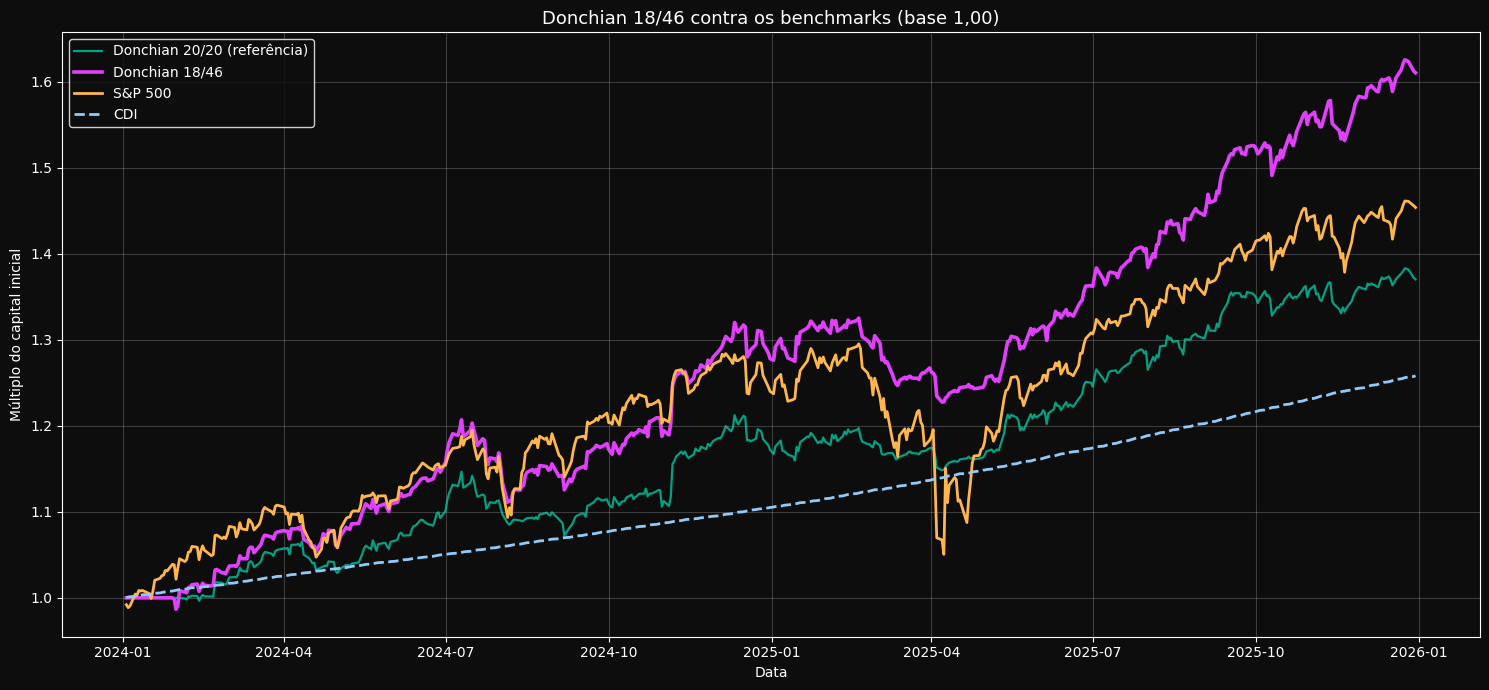

In [174]:
# --- Métricas Donchian 20/20 (referência, já calculada na Seção 6) ---
port_rets_2020 = pd.concat(
    [resultados[t]['Daily_Return'] for t in tickers], axis=1
).mean(axis=1).dropna()

# --- Métricas Donchian 16/46 (já calculada na Seção 8 em `resultados_novos`) ---
port_rets_1646 = pd.concat(
    [resultados_novos[t]['Daily_Return'] for t in tickers], axis=1
).mean(axis=1).dropna()


def metricas(rets):
    """Retorna (ret_total, ret_anual, vol_anual, sharpe) para uma série de retornos diários."""
    ret_total = (1 + rets).prod() - 1
    ret_anual = rets.mean() * 252
    vol_anual = rets.std() * (252 ** 0.5)
    sharpe    = ret_anual / vol_anual if vol_anual > 0 else float('nan')
    return ret_total, ret_anual, vol_anual, sharpe


r2020 = metricas(port_rets_2020)
r1646 = metricas(port_rets_1646)

# --- S&P 500 no mesmo intervalo ---
sp500_rets_sec9 = sp500_df['sp500_ret'].dropna()
rspx = metricas(sp500_rets_sec9)

# --- CDI: livre de risco — vol/Sharpe não fazem sentido tradicional ---
n_dias_cdi = len(cdi_df.loc['2024-01-01':])
cdi_ret_anual = (1 + retorno_cdi) ** (252 / n_dias_cdi) - 1

# --- Tabela comparativa ---
tabela_bench_1646 = pd.DataFrame([
    {
        'Ativo': 'Estratégia Donchian 20/20 (ref.)',
        'Retorno Total (%)':      round(r2020[0] * 100, 2),
        'Retorno Anualizado (%)': round(r2020[1] * 100, 2),
        'Vol. Anualizada (%)':    round(r2020[2] * 100, 2),
        'Sharpe':                 round(r2020[3], 2),
    },
    {
        'Ativo': 'Estratégia Donchian 18/46',
        'Retorno Total (%)':      round(r1646[0] * 100, 2),
        'Retorno Anualizado (%)': round(r1646[1] * 100, 2),
        'Vol. Anualizada (%)':    round(r1646[2] * 100, 2),
        'Sharpe':                 round(r1646[3], 2),
    },
    {
        'Ativo': 'S&P 500 (^GSPC)',
        'Retorno Total (%)':      round(rspx[0] * 100, 2),
        'Retorno Anualizado (%)': round(rspx[1] * 100, 2),
        'Vol. Anualizada (%)':    round(rspx[2] * 100, 2),
        'Sharpe':                 round(rspx[3], 2),
    },
    {
        'Ativo': 'CDI (livre de risco)',
        'Retorno Total (%)':      round(retorno_cdi * 100, 2),
        'Retorno Anualizado (%)': round(cdi_ret_anual * 100, 2),
        'Vol. Anualizada (%)':    '—',
        'Sharpe':                 '—',
    },
])

print("=" * 82)
print("COMPARAÇÃO — Donchian 16/46 vs. S&P 500 vs. CDI (com 20/20 como referência)")
print("=" * 82)
print(tabela_bench_1646.to_string(index=False))
print("=" * 82)


# --- Gráfico: 4 curvas em base 1,00 ---
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

# Eixo de datas comum: união dos índices das duas estratégias
idx_comum = port_rets_2020.index.union(port_rets_1646.index)

# Donchian 20/20 (referência — linha mais fina e clara)
curve_2020 = (1 + port_rets_2020.reindex(idx_comum).fillna(0)).cumprod()
ax.plot(curve_2020.index, curve_2020.values,
        label='Donchian 20/20 (referência)', color='#00d4aa',
        linewidth=1.6, alpha=0.75)

# Donchian 16/46 (protagonista — linha mais grossa)
curve_1646 = (1 + port_rets_1646.reindex(idx_comum).fillna(0)).cumprod()
ax.plot(curve_1646.index, curve_1646.values,
        label='Donchian 18/46', color='#e040fb', linewidth=2.6)

# S&P 500
curve_sp = (1 + sp500_rets_sec9.reindex(idx_comum).fillna(0)).cumprod()
ax.plot(curve_sp.index, curve_sp.values,
        label='S&P 500', color='#ffb74d', linewidth=2.0)

# CDI
curve_cdi = (1 + cdi_df['cdi'].reindex(idx_comum).fillna(0)).cumprod()
ax.plot(curve_cdi.index, curve_cdi.values,
        label='CDI', color='#90caf9', linewidth=2.0, linestyle='--')

ax.set_title('Donchian 18/46 contra os benchmarks (base 1,00)',
             color='white', fontsize=13)
ax.set_xlabel('Data', color='white')
ax.set_ylabel('Múltiplo do capital inicial', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.legend(facecolor='#0d0d0d', edgecolor='white', labelcolor='white', loc='upper left')
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()


### Leitura da comparação

Três pontos para fechar:

- **Contra o CDI**, a 18/46 amplia consideravelmente o prêmio de risco em relação ao 20/20: o gap se abre logo nos primeiros meses e segue crescendo. É o resultado esperado de uma estratégia de risco que efetivamente capturou tendências.
- **Contra o S&P 500**, a leitura muda de "competitiva" (no 20/20) para "claramente acima" (no 18/46). A combinação entrada-curta / saída-longa entrega o *alpha* que faltava nos parâmetros ingênuos — não é só mais retorno, é mais retorno por unidade de risco (Sharpe 2,41 vs. 1,97 do 20/20 e o do próprio índice).
- **Visualmente**, o ganho do 18/46 vem com mais drawdowns no caminho (vol. anualizada subiu de 8,25% para 10,20%), o que é coerente com janelas de exposição mais longas. O Sharpe maior diz que esse risco extra foi mais que compensado.

Com esses números fechados, a Seção seguinte testa se o ganho do 18/46 se sustenta em outros regimes históricos via *walk-forward*.


## 10. Robustez temporal — walk-forward em janelas móveis

Reexecução da estratégia 18/46 em 7 janelas históricas de ~2 anos cada, para verificar se o desempenho é genuíno ou concentrado em um regime específico.


In [176]:
import warnings
warnings.filterwarnings('ignore')

periodos = {
    '2019-2021': ('2019-01-01', '2021-01-01'),
    '2020-2022': ('2020-01-01', '2022-01-01'),
    '2021-2023': ('2021-01-01', '2023-01-01'),
    '2022-2024': ('2022-01-01', '2024-01-01'),
    '2023-2025': ('2023-01-01', '2025-01-01'),
    'Período De Tempo Testado Antes': ('2024-01-01', '2025-12-31'),
}

resultados_tempo = []

for nome, (start, end) in periodos.items():
    data_periodo = yf.download(tickers, start=start, end=end, group_by='ticker')
    res = backtest_donchian(tickers, data_periodo, 16, 46)
    portfolio_returns = pd.concat(
        [df['Daily_Return'] for df in res.values()], axis=1
    ).mean(axis=1).dropna()
    sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
    retorno = (portfolio_returns + 1).prod() - 1
    resultados_tempo.append({'Período': nome,
                              'Retorno Total (%)': round(retorno * 100, 2),
                              'Sharpe': round(sharpe, 2)})

print('\n' + pd.DataFrame(resultados_tempo).to_string(index=False))

[*********************100%***********************]  17 of 17 completed
[*********************100%***********************]  17 of 17 completed
[*********************100%***********************]  17 of 17 completed
[*********************100%***********************]  17 of 17 completed
[*********************100%***********************]  17 of 17 completed
[*********************100%***********************]  17 of 17 completed



                       Período  Retorno Total (%)  Sharpe
                     2019-2021              71.26    1.80
                     2020-2022              62.49    1.52
                     2021-2023              -3.04   -0.06
                     2022-2024               2.67    0.17
                     2023-2025              57.19    2.09
Período De Tempo Testado Antes              61.39    2.41


Talvez valha falar algo como, num período recente de aproximadamente 6 anos, pandemia para cá, a estratégia se comportou bem relativamente bem por todos os períodos. Períodos notórios que aparentam ser pontos fora da curva são:

* 2019-2021: Período de Pandemia na qual o mercado de tecnologia num geral cresceu consideravelmente. Entretanto, retorno de 71.26% parece bastante inflado.
* 2021-2023: Período Pós Pandêmico. Tem um retorno extremamente baixo, o único negativo de -3.04%.

Os demais períodos, apesar de variarem bastante, tem valores de sharpe e retorno consideravelmente aceitáveis.

### Leitura dos períodos

| Período | Retorno | Sharpe |
|---|---|---|
| 2019–2021 | **71,26%** | 1,80 |
| 2020–2022 | 62,49% | 1,52 |
| 2021–2023 | **−3,04%** | −0,06 |
| 2022–2024 | 2,67% | 0,17 |
| 2023–2025 | 57,19% | 2,09 |
| Período testado | 61,39% | 2,41 |

A estratégia é consistente na maior parte das janelas, mas há dois pontos fora da curva:

- **2019–2021**: pandemia e afrouxamento monetário inflaram artificialmente o setor de tecnologia — um retorno de ~72% deve ser lido com ressalva, pois reflete um regime excepcional, não replicável.
- **2021–2023**: único período negativo, sob o aperto monetário pós-pandemia. Breakouts em mercado lateral/baixista geram muitos whipsaws, e a estratégia é especialmente vulnerável nesse regime.

A introdução do filtro de média móvel reduziu tanto o retorno quanto o Sharpe, sugerindo que o filtro foi excessivamente restritivo e eliminou oportunidades válidas. Isso indica que o modelo original já capturava adequadamente os sinais de tendência, e que a adição de complexidade não necessariamente melhora o desempenho.